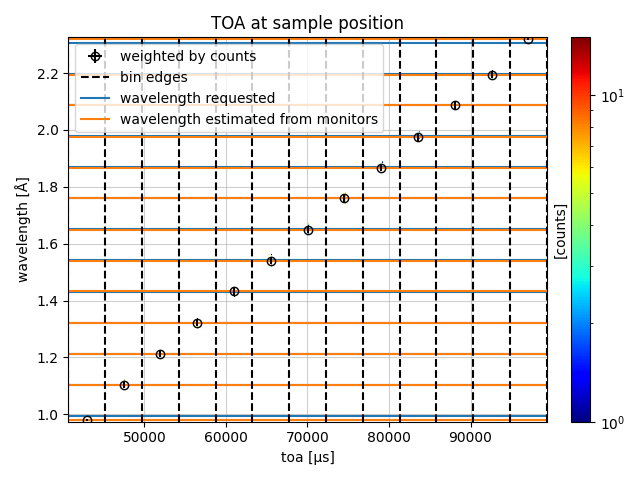

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.components.source import Source

central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
# trex.source = Source(facility="ess", neutrons=100_000, pulses=2)
wavelength_requested = trex.calculate_incoming_wavelength()
res = trex.run()
wavelength_estimated = trex.estimate_incoming_wavelength(model_result=res)


fig, ax = plt.subplots()

for wa in wavelength_requested:
    hline_ei = ax.axhline(
        y=wa.values, c="C0", linestyle="-", label="wavelength requested"
    )
for wa in wavelength_estimated:
    hline_ei_est = ax.axhline(
        y=wa.values, c="C1", linestyle="-", label="wavelength estimated from monitors"
    )

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data["pulse", 0]
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
# Histogram and plot
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(
    norm="log", cbar=True, ax=ax, cmap="jet", title="TOA at sample position"
)

toa_bin_edges = trex.monitors["Monitor at Sample"].calculate_toa_bin_edges()
toa_binned = events_at_sample.bin(toa=toa_bin_edges)

for edge in toa_bin_edges:
    vline_edges = ax.axvline(x=edge.values, c="k", linestyle="--", label="bin edges")


# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["wavelength"]
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["wavelength"] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# Weighted mean of TOA inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["toa"]
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["toa"] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot = ax.errorbar(
    x=toa_mu.values,
    xerr=sc.sqrt(toa_var.hist()).values,
    y=wavelength_mu.values,
    yerr=sc.sqrt(wavelength_var.hist()).values,
    fmt="ok",
    linestyle="",
    mfc="none",
    label="weighted by counts",
)
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[ebplot, vline_edges, hline_ei, hline_ei_est], loc=0)
fig.tight_layout()
plt.show()

In [2]:
print(trex.source)

Source:
  pulses=1, neutrons per pulse=1000000
  frequency=14.0 Hz
  facility='ess'
  distance=0.05 m
  time range=(2.943, 4358.063) [µs]
  wavelength range=(0.110, 6.449) [Å]


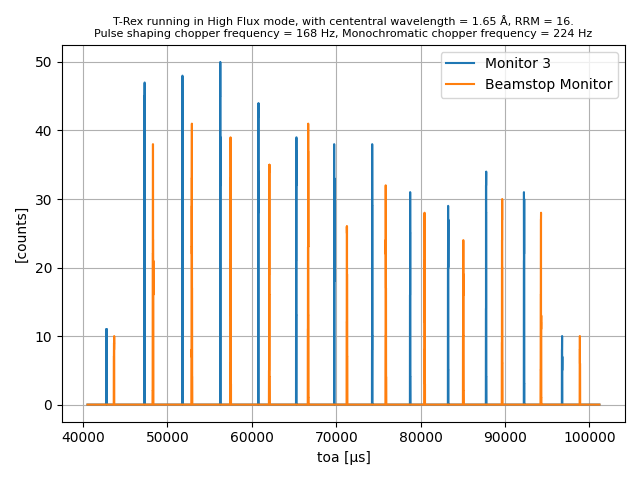

In [3]:
import plopp as pp

toa_m3_edges = trex.monitors["Monitor 3"].calculate_toa_bin_edges()
toa_det_edges = trex.monitors["Beamstop Monitor"].calculate_toa_bin_edges()


toa_bin_to_plot = sc.linspace(
    "toa", toa_m3_edges.min(), toa_det_edges.max(), num=500 * (len(toa_m3_edges) - 1)
)
hist_m3 = res.detectors["Monitor 3"].data.hist(toa=toa_bin_to_plot)
hist_det = res.detectors["Beamstop Monitor"].data.hist(toa=toa_bin_to_plot)


fig, ax = plt.subplots()
pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

In [4]:
res = trex.model.run()
toa_centers_m3 = trex.monitors["Monitor 3"].estimate_toa_centroid(model_result=res)
toa_centers_bs = trex.monitors["Beamstop Monitor"].estimate_toa_centroid(
    model_result=res
)

print(toa_centers_m3.data)
print(toa_centers_bs.data)

<scipp.Variable> (rrm: 13)    float64            [µs]  [42781.2, 47282.3, ..., 92254.7, 96755.7]
<scipp.Variable> (rrm: 13)    float64            [µs]  [43672.9, 48287.3, ..., 94251.2, 98866.8]


In [5]:
wavelength = trex.estimate_incoming_wavelength(res)
wavelength_requested = trex.calculate_incoming_wavelength()

print(wavelength)
print(wavelength_requested)
print(wavelength_requested.values)

<scipp.Variable> (rrm: 13)    float64             [Å]  [0.979949, 1.10436, ..., 2.19402, 2.31983]
<scipp.Variable> (rrm: 13)    float64             [Å]  [0.995894, 1.10491, ..., 2.19509, 2.30411]
[0.99589385 1.10491154 1.21392923 1.32294692 1.43196462 1.54098231
 1.65       1.75901769 1.86803538 1.97705308 2.08607077 2.19508846
 2.30410615]


In [6]:
ei = trex.estimate_ei(res)
ei_requested = trex.calculate_ei()

print(ei)
print(ei_requested)
print(ei.values)

<scipp.Variable> (rrm: 13)    float64            [meV]  [85.1861, 67.0744, ..., 16.9939, 15.2006]
<scipp.Variable> (rrm: 13)    float64            [meV]  [82.4802, 67.0071, ..., 16.9774, 15.4089]
[85.18610017 67.0744269  55.59445449 46.82737853 39.86509596 34.48668586
 30.07544545 26.43514707 23.48845951 20.96935647 18.79947426 16.99389294
 15.20063182]


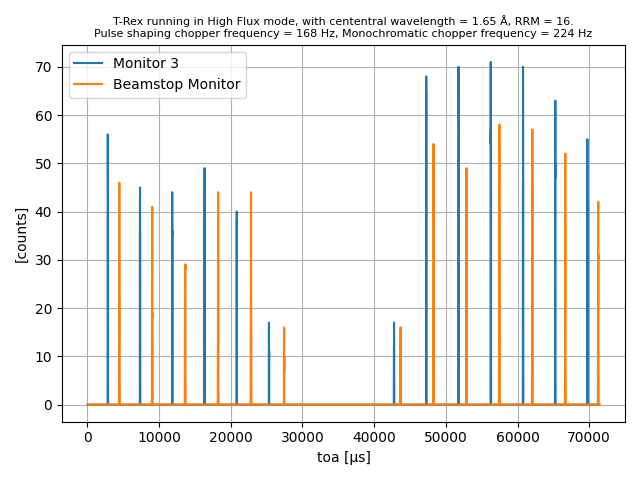

In [7]:
trex.wrap_frame(res)

hist_m3 = res["Monitor 3"].data.hist(toa=5000)
hist_det = res["Beamstop Monitor"].data.hist(toa=5000)

fig, ax = plt.subplots()
pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

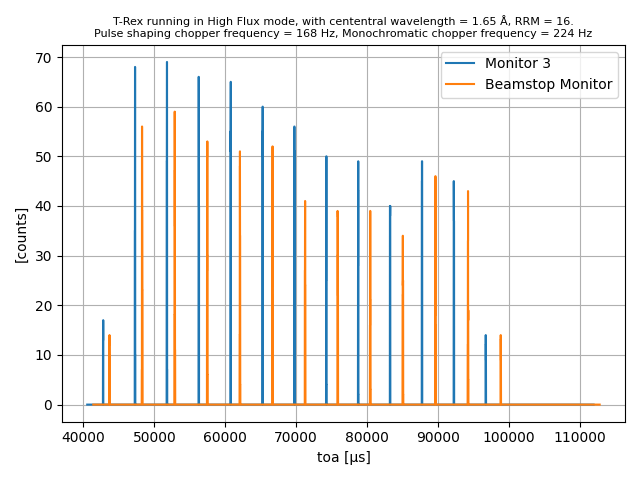

In [8]:
trex.unwrap_frame(res)

hist_m3 = res["Monitor 3"].data.hist(toa=5000)
hist_det = res["Beamstop Monitor"].data.hist(toa=5000)

fig, ax = plt.subplots()
pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

In [9]:
wavelength = trex.estimate_incoming_wavelength(res)
print(wavelength)
ei = trex.estimate_ei(res)
print(ei.values)

<scipp.Variable> (rrm: 13)    float64             [Å]  [0.979949, 1.10436, ..., 2.19402, 2.31983]
[85.18610017 67.0744269  55.59445449 46.82737853 39.86509596 34.48668586
 30.07544545 26.43514707 23.48845951 20.96935647 18.79947426 16.99389294
 15.20063182]
